---

# ASSIGNMENT 6: ROLLING AGGREGATIONS

---

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style('darkgrid')

In [2]:
transactions = pd.read_parquet('../Data/transactions.parquet')
transactions.info(memory_usage='deep')

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 83488 entries, 0 to 83487
Data columns (total 3 columns):
 #   Column        Non-Null Count  Dtype         
---  ------        --------------  -----         
 0   date          83488 non-null  datetime64[ns]
 1   store_nbr     83488 non-null  int64         
 2   transactions  83488 non-null  int64         
dtypes: datetime64[ns](1), int64(2)
memory usage: 1.9 MB


In [3]:
transactions.head(3)

,date,store_nbr,transactions
0,2013-01-01,25,770
1,2013-01-02,1,2111
2,2013-01-02,2,2358


<br><br>

---

In [7]:
df = transactions.query("store_nbr == 47")[['date', 'transactions']]
df = df.set_index('date')
df

,transactions
date,
2013-01-02,4161
2013-01-03,3660
2013-01-04,3915
2013-01-05,4764
2013-01-06,4935
...,...
2017-08-11,4009
2017-08-12,3825
2017-08-13,3741


In [8]:
df['transactions_rolling_avg_90'] = df.rolling(90).mean()
df

,transactions,transactions_rolling_avg_90
date,,
2013-01-02,4161,NaN
2013-01-03,3660,NaN
2013-01-04,3915,NaN
2013-01-05,4764,NaN
2013-01-06,4935,NaN
...,...,...
2017-08-11,4009,3838.744444
2017-08-12,3825,3832.100000
2017-08-13,3741,3835.388889


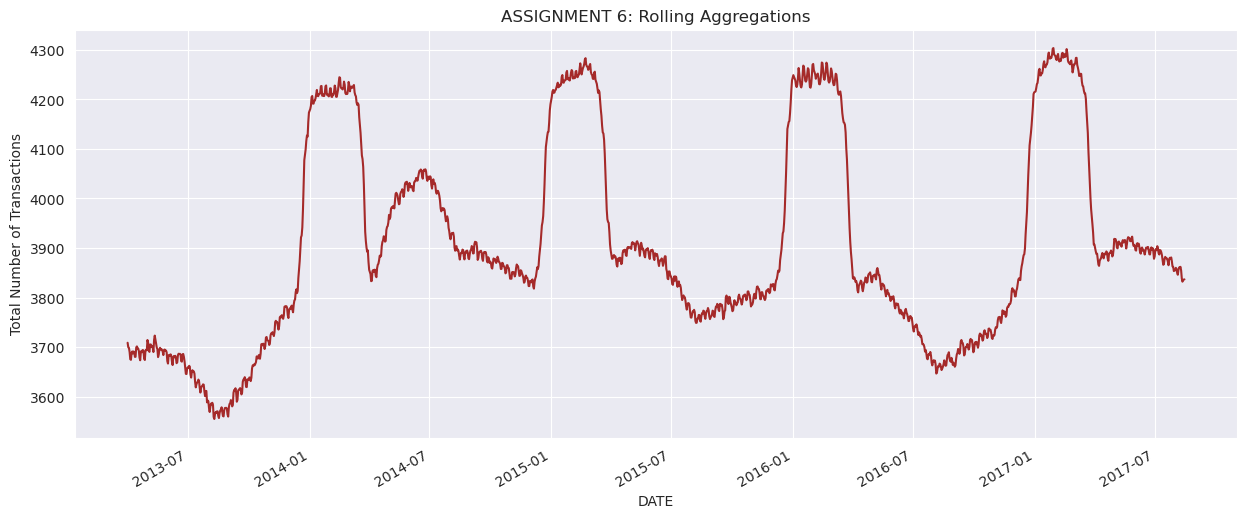

In [14]:
df.transactions_rolling_avg_90.plot(
    figsize=(15, 6),
    title='ASSIGNMENT 6: Rolling Aggregations',
    xlabel='DATE',
    ylabel='Total Number of Transactions',
    color='brown'
);